In [ ]:
# Задача 4.1.

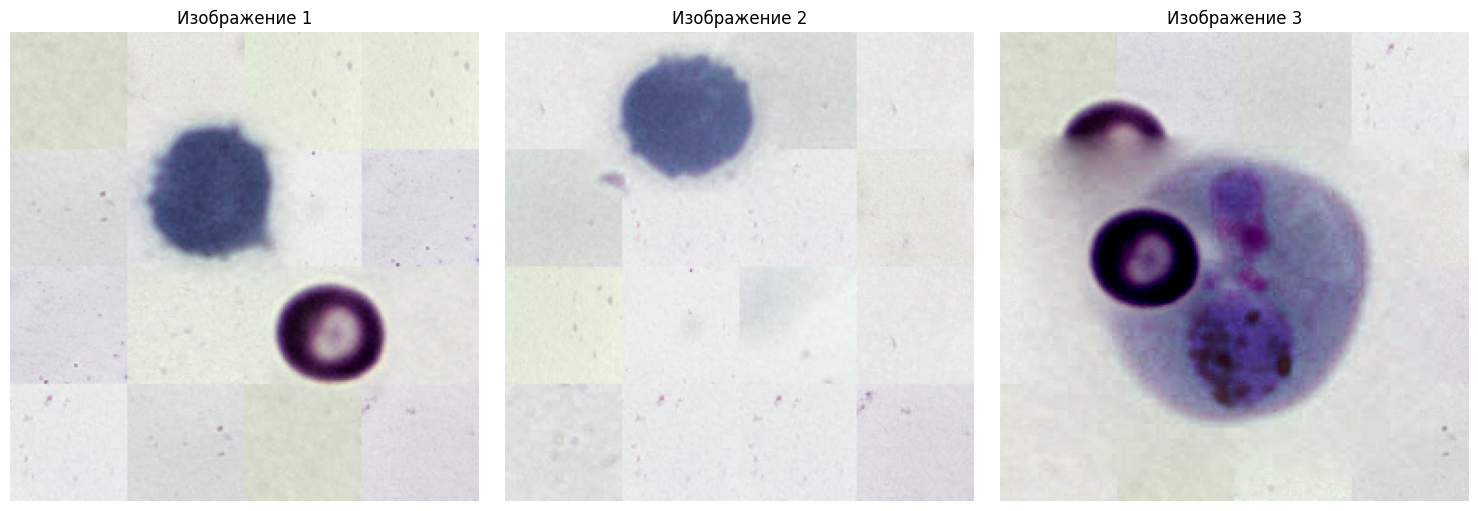


 Сравнение изображений
          SSIM      MSE
.png  1.000000  0.00000
.jpg  0.986225  1.45696
.bmp  1.000000  0.00000


In [4]:
import cv2
import numpy as np
import random
import os
from glob import glob
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from sklearn.metrics import mean_squared_error
import pandas as pd

IMAGE_SIZE = (256, 256)
NUM_CELLS_RANGE = (1, 5)

def create_background_from_patches(image_size=(256, 256), patch_dir="blood_cells_dataset/fon"):
    background = np.zeros((image_size[1], image_size[0], 3), dtype=np.uint8)
    patch_size = (64, 64)  

    patch_files = glob(os.path.join(patch_dir, "*.png"))
    if not patch_files:
        raise FileNotFoundError(f"Не найдены изображения в директории {patch_dir}")
    
    num_patches_x = image_size[0] // patch_size[0]
    num_patches_y = image_size[1] // patch_size[1]
    
    for i in range(num_patches_y):
        for j in range(num_patches_x):
            patch = cv2.imread(random.choice(patch_files), cv2.IMREAD_COLOR)  # Используем цветное изображение
            if patch is None:
                print(f"Ошибка при загрузке патча из {patch_files[0]}")
                continue
            patch = cv2.resize(patch, patch_size)
            background[i * patch_size[1]:(i + 1) * patch_size[1], j * patch_size[0]:(j + 1) * patch_size[0]] = patch
            
    return background

def place_cell(background, cell):
    bg_h, bg_w, _ = background.shape
    cell_h, cell_w, _ = cell.shape
    mask = 255 * np.ones((cell_h, cell_w), dtype=np.uint8)
    x = random.randint(0, bg_w - cell_w)
    y = random.randint(0, bg_h - cell_h)
    center = (x + cell_w // 2, y + cell_h // 2)
    background = cv2.seamlessClone(cell, background, mask, center, cv2.NORMAL_CLONE)
    return background

def data_generator(cell_patch_dir="blood_cells_dataset/patch", use_generated_circles=True):
    while True:
        background = create_background_from_patches()
        clean_image = background.copy()
        num_cells = random.randint(NUM_CELLS_RANGE[0], NUM_CELLS_RANGE[1])
        cell_files = glob(os.path.join(cell_patch_dir, "*.png"))
        
        for _ in range(num_cells):
            cell = cv2.imread(random.choice(cell_files), cv2.IMREAD_COLOR)  
            if cell is None:
                print("Ошибка при загрузке клетки")
                continue
            
            bg_h, bg_w, _ = clean_image.shape
            cell_h, cell_w, _ = cell.shape
            x = random.randint(0, bg_w - cell_w)
            y = random.randint(0, bg_h - cell_h)
            clean_image = place_cell(clean_image, cell)
        
        yield clean_image

output_dir = "generated_images"
os.makedirs(output_dir, exist_ok=True) 

generator = data_generator()
num_images_to_generate = 3
image_formats = [".png", ".jpg", ".bmp"]
generated_images = []

for i in range(num_images_to_generate):
    clean_image = next(generator)
    generated_images.append(clean_image)
    for format in image_formats:
        filename = os.path.join(output_dir, f"clean_image_{i}{format}")
        if format == ".jpg":
            cv2.imwrite(filename, clean_image, [int(cv2.IMWRITE_JPEG_QUALITY), 100])  
        else:
            cv2.imwrite(filename, clean_image)

plt.figure(figsize=(15, 5)) 
for i, clean_image in enumerate(generated_images):
    plt.subplot(1, num_images_to_generate, i + 1) 
    plt.imshow(cv2.cvtColor(clean_image, cv2.COLOR_BGR2RGB))  
    plt.title(f"Изображение {i+1}")
    plt.axis('off')
plt.tight_layout() 
plt.show()

# сравнение изображений 
print("\n Сравнение изображений")
results = {}
for format in image_formats:
    results[format] = {"SSIM": [], "MSE": []}

for i in range(num_images_to_generate):
    original_image = cv2.imread(os.path.join(output_dir, f"clean_image_{i}.png"))
    original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
    for format in image_formats:
        filename = os.path.join(output_dir, f"clean_image_{i}{format}")
        loaded_image = cv2.imread(filename)
        if loaded_image is None:
            print(f"Error loading image from {filename}")
            continue
        loaded_image = cv2.cvtColor(loaded_image, cv2.COLOR_BGR2RGB)
        if original_image.shape == loaded_image.shape:
            ssim_score = ssim(original_image, loaded_image, channel_axis=-1, data_range=loaded_image.max() - loaded_image.min())
            mse_score = mean_squared_error(original_image.flatten(), loaded_image.flatten())
        else:
            ssim_score = np.nan 
            mse_score = np.nan
        results[format]["SSIM"].append(ssim_score)
        results[format]["MSE"].append(mse_score)

table_data = {}
for format in image_formats:
    table_data[format] = {
        "SSIM": np.nanmean(results[format]["SSIM"]),
        "MSE": np.nanmean(results[format]["MSE"])
    }
df = pd.DataFrame.from_dict(table_data, orient="index")
print(df)

In [ ]:
# Задача 4.2.1

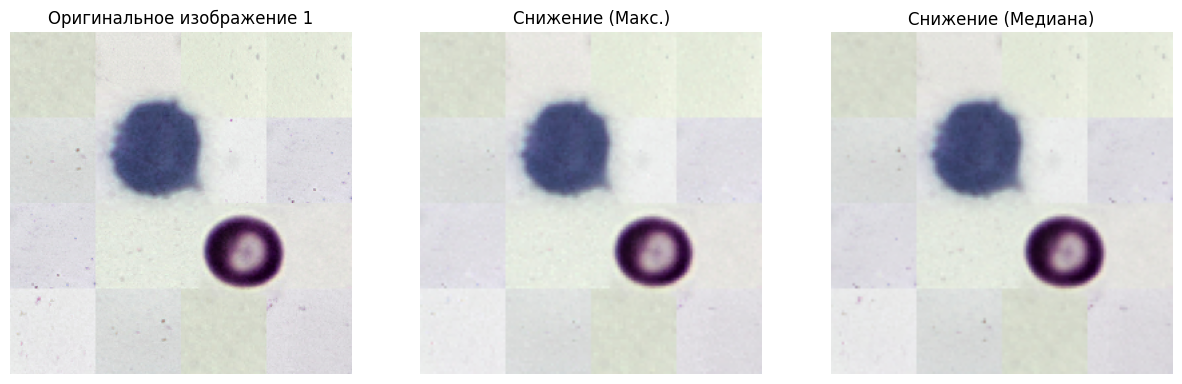

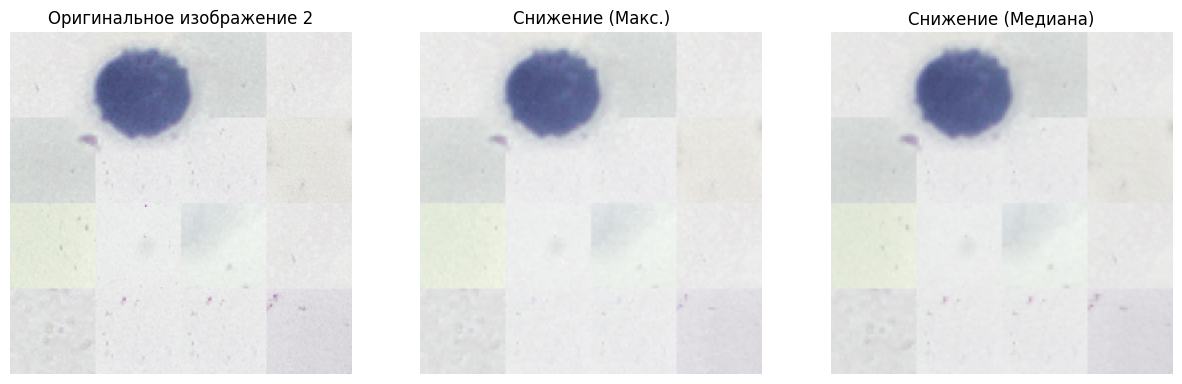

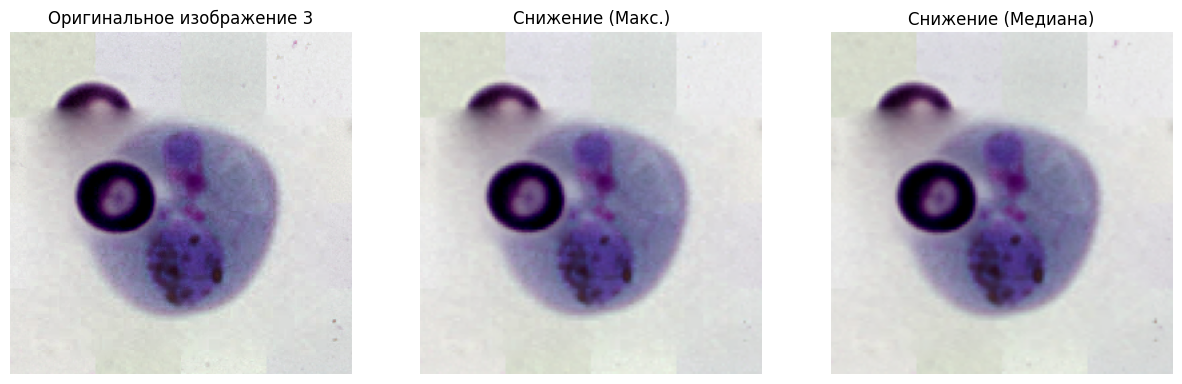

SSIM (Макс.): [np.float64(0.9615648954470503), np.float64(0.9474023404418522), np.float64(0.9746886825859988)]
MSE (Макс.): [19.499674479166668, 9.9969482421875, 19.748758951822918]
SSIM (Медиана): [np.float64(0.9921030648918038), np.float64(0.9888243618305775), np.float64(0.9957290436487605)]
MSE (Медиана): [0.82513427734375, 0.6817830403645834, 0.6671142578125]


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from sklearn.metrics import mean_squared_error
import os

def downsample_max(image, factor):
    h, w, c = image.shape
    new_h = h // factor
    new_w = w // factor
    downsampled = np.zeros((new_h, new_w, c), dtype=image.dtype)
    for i in range(new_h):
        for j in range(new_w):
            block = image[i * factor:(i + 1) * factor, j * factor:(j + 1) * factor]
            downsampled[i, j] = np.max(block, axis=(0, 1)) 
    return downsampled.astype(np.uint8)

def downsample_median(image, factor):
    h, w, c = image.shape
    new_h = h // factor
    new_w = w // factor
    downsampled = np.zeros((new_h, new_w, c), dtype=image.dtype)
    for i in range(new_h):
        for j in range(new_w):
            block = image[i * factor:(i + 1) * factor, j * factor:(j + 1) * factor]
            downsampled[i, j] = np.median(block, axis=(0, 1))  
    return downsampled.astype(np.uint8)

image_folder = 'generated_images'  
image_format = ".png"  
downsample_factor = 2  
ssim_max_values = []
mse_max_values = []
ssim_median_values = []
mse_median_values = []

num_images = 3  

for i in range(num_images):
    image_path = os.path.join(image_folder, f'clean_image_{i}{image_format}')
    original_image = cv2.imread(image_path)
    if original_image is None:
        print(f"Error loading image from {image_path}")
        continue
    original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB) 
    downsampled_max_image = downsample_max(original_image.copy(), downsample_factor)
    downsampled_median_image = downsample_median(original_image.copy(), downsample_factor)
    
    cv2.imwrite(os.path.join(image_folder, f"clean_image_{i}_downsampled_max{image_format}"), downsampled_max_image) 
    cv2.imwrite(os.path.join(image_folder, f"clean_image_{i}_downsampled_median{image_format}"), downsampled_median_image)
    
    resized_original_image = cv2.resize(original_image, (downsampled_max_image.shape[1], downsampled_max_image.shape[0]), interpolation=cv2.INTER_LINEAR)
    ssim_max = ssim(resized_original_image, downsampled_max_image, channel_axis=-1, data_range=downsampled_max_image.max() - downsampled_max_image.min())
    mse_max = mean_squared_error(resized_original_image.flatten(), downsampled_max_image.flatten())
    ssim_max_values.append(ssim_max)
    mse_max_values.append(mse_max)
    
    ssim_median = ssim(resized_original_image, downsampled_median_image, channel_axis=-1, data_range=downsampled_median_image.max() - downsampled_median_image.min())
    mse_median = mean_squared_error(resized_original_image.flatten(), downsampled_median_image.flatten())
    ssim_median_values.append(ssim_median)
    mse_median_values.append(mse_median)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(original_image)
    plt.title(f"Оригинальное изображение {i+1}")
    plt.axis('off')
    plt.subplot(1, 3, 2)
    plt.imshow(downsampled_max_image)
    plt.title("Снижение (Макс.)")
    plt.axis('off')
    plt.subplot(1, 3, 3)
    plt.imshow(downsampled_median_image)
    plt.title("Снижение (Медиана)")
    plt.axis('off')
    plt.show()

# Вывод метрик
print("SSIM (Макс.):", ssim_max_values)
print("MSE (Макс.):", mse_max_values)
print("SSIM (Медиана):", ssim_median_values)
print("MSE (Медиана):", mse_median_values)

In [ ]:
# Задача 4.2.2

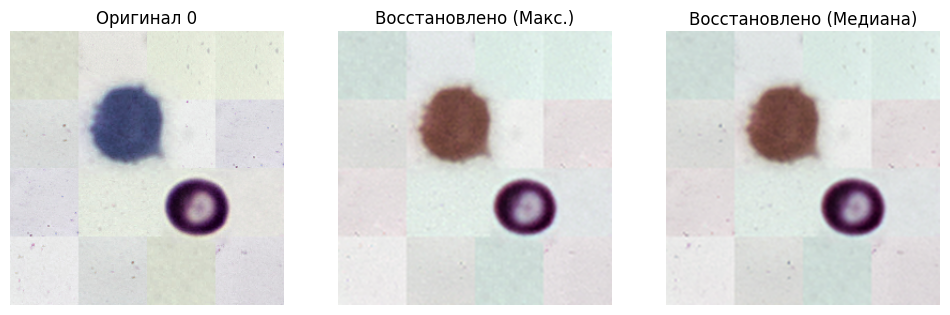

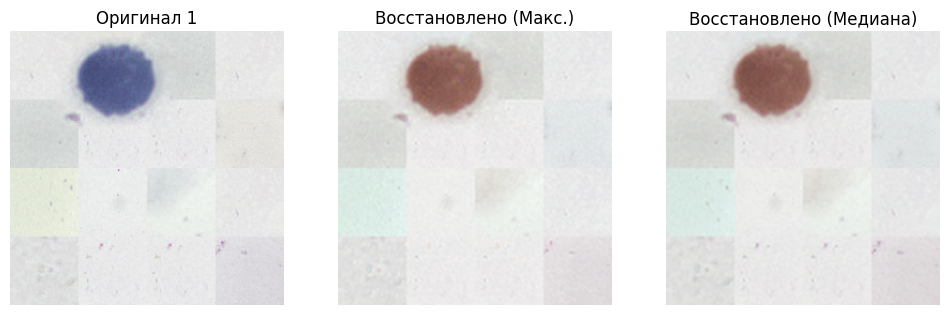

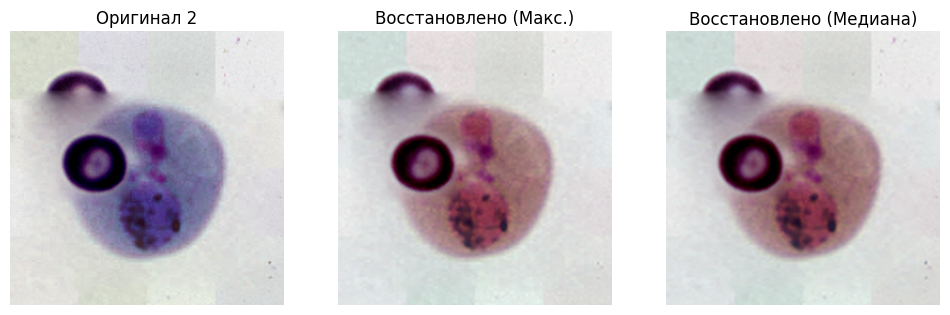


Сравнение метрик восстановления изображений

Изображение #1:
  - SSIM для изображения с методом максимума: 0.8786
  - MSE для изображения с методом максимума: 147.22
  - SSIM для изображения с медианным методом: 0.8983
  - MSE для изображения с медианным методом: 126.88

Изображение #2:
  - SSIM для изображения с методом максимума: 0.8396
  - MSE для изображения с методом максимума: 127.69
  - SSIM для изображения с медианным методом: 0.8663
  - MSE для изображения с медианным методом: 117.92

Изображение #3:
  - SSIM для изображения с методом максимума: 0.8884
  - MSE для изображения с методом максимума: 259.44
  - SSIM для изображения с медианным методом: 0.9033
  - MSE для изображения с медианным методом: 233.77


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from sklearn.metrics import mean_squared_error
import os

def upscale_lanczos(image, scale=2):
    h, w = image.shape[:2]
    new_h, new_w = h * scale, w * scale
    return cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LANCZOS4)

# параметры
image_folder = 'generated_images'  
image_format = ".png"  
downsample_factor = 2  
num_images = 3  

ssim_lanczos_values = []
mse_lanczos_values = []

# обработка изображения
for i in range(num_images):
    image_path_original = os.path.join(image_folder, f'clean_image_{i}{image_format}')
    image_path_max = os.path.join(image_folder, f'clean_image_{i}_downsampled_max{image_format}')
    image_path_median = os.path.join(image_folder, f'clean_image_{i}_downsampled_median{image_format}')
    
    original_image = cv2.imread(image_path_original)
    downsampled_max_image = cv2.imread(image_path_max)
    downsampled_median_image = cv2.imread(image_path_median)
    
    if original_image is None or downsampled_max_image is None or downsampled_median_image is None:
        print(f"Ошибка при загрузке изображений для {image_path_original}, {image_path_max} или {image_path_median}")
        continue
    
    # конвертация
    original_image_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
    downsampled_max_image_rgb = cv2.cvtColor(downsampled_max_image, cv2.COLOR_BGR2RGB)
    downsampled_median_image_rgb = cv2.cvtColor(downsampled_median_image, cv2.COLOR_BGR2RGB)

    # масштабирование изображения с помощью Ланцоша
    upscaled_max_image = upscale_lanczos(downsampled_max_image_rgb, scale=downsample_factor)
    upscaled_median_image = upscale_lanczos(downsampled_median_image_rgb, scale=downsample_factor)

    # восстановление
    resized_original_max = cv2.resize(original_image_rgb, (upscaled_max_image.shape[1], upscaled_max_image.shape[0]), interpolation=cv2.INTER_LINEAR)
    resized_original_median = cv2.resize(original_image_rgb, (upscaled_median_image.shape[1], upscaled_median_image.shape[0]), interpolation=cv2.INTER_LINEAR)

    # расчет SSIM и MSE для изображения с max downsampling
    ssim_max = ssim(resized_original_max, upscaled_max_image, channel_axis=-1, data_range=upscaled_max_image.max() - upscaled_max_image.min())
    mse_max = mean_squared_error(resized_original_max.flatten(), upscaled_max_image.flatten())

    # расчет SSIM и MSE для изображения с median downsampling
    ssim_median = ssim(resized_original_median, upscaled_median_image, channel_axis=-1, data_range=upscaled_median_image.max() - upscaled_median_image.min())
    mse_median = mean_squared_error(resized_original_median.flatten(), upscaled_median_image.flatten())

    ssim_lanczos_values.append((ssim_max, ssim_median))
    mse_lanczos_values.append((mse_max, mse_median))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(original_image_rgb)
    plt.title(f"Оригинал {i}")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(upscaled_max_image)
    plt.title("Восстановлено (Макс.)")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(upscaled_median_image)
    plt.title("Восстановлено (Медиана)")
    plt.axis('off')

    plt.show()

print("\nСравнение метрик восстановления изображений")
for i in range(num_images):
    ssim_max, ssim_median = ssim_lanczos_values[i]
    mse_max, mse_median = mse_lanczos_values[i]
    
    print(f"\nИзображение #{i+1}:")
    print(f"  - SSIM для изображения с методом максимума: {ssim_max:.4f}")
    print(f"  - MSE для изображения с методом максимума: {mse_max:.2f}")
    
    print(f"  - SSIM для изображения с медианным методом: {ssim_median:.4f}")
    print(f"  - MSE для изображения с медианным методом: {mse_median:.2f}")